Training set: (9458, 28, 28, 1), Test set: (0, 28, 28, 1)


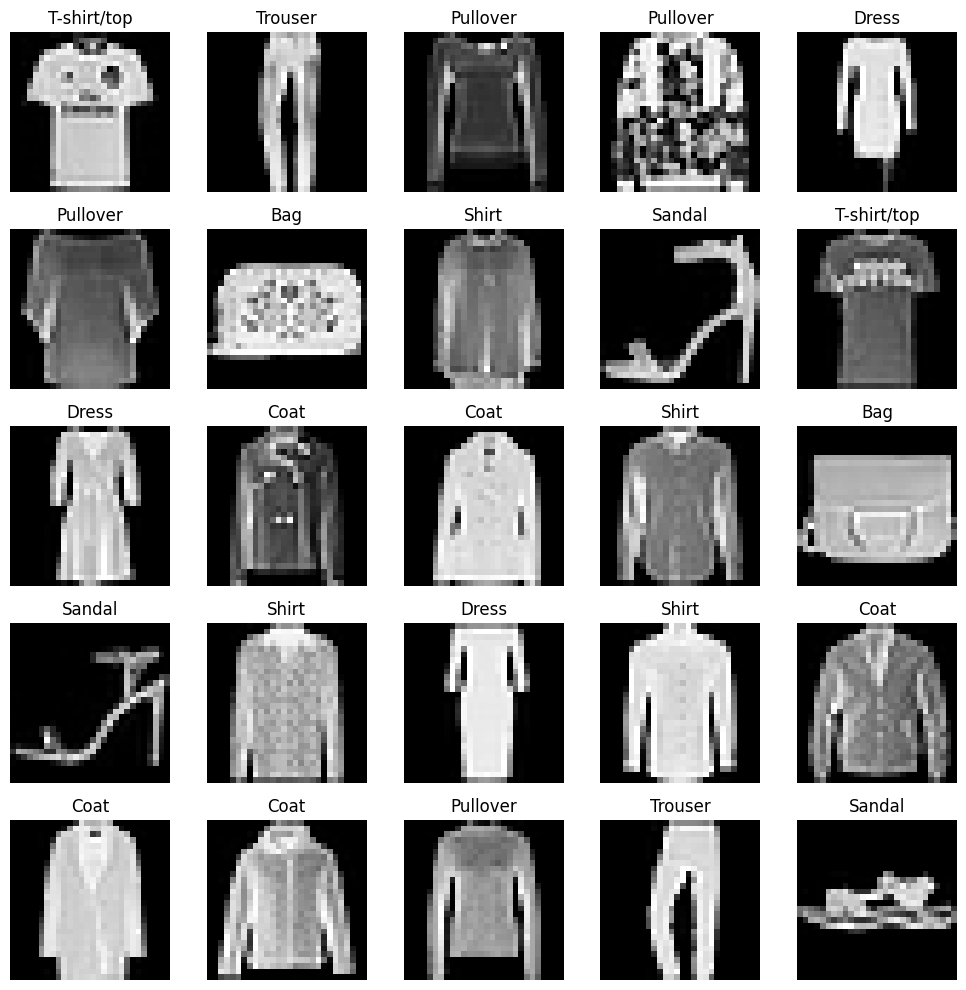

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load CSV file
# Change 'fashion_mnist.csv' to your actual file path
df = pd.read_csv('/content/fashion-mnist_test.csv')

# Separate labels and pixels
# If header exists, use df.columns; else set header=None
if 'label' in df.columns:
    labels = df['label'].values
    pixels = df.drop('label', axis=1).values
else:
    # Assume first column is label, rest are pixels
    labels = df.iloc[:, 0].values
    pixels = df.iloc[:, 1:].values

# Reshape pixels to 28x28 images
num_samples = pixels.shape[0]
images = pixels.reshape(num_samples, 28, 28)

# Normalize to [0,1]
images = images.astype('float32') / 255.0

# Add channel dimension if needed for Conv2D later
images = np.expand_dims(images, axis=-1)  # (num_samples, 28, 28, 1)

# Split into train/test (Fashion-MNIST standard is 60000 train, 10000 test)
# If your CSV contains all 70000, split accordingly:
train_size = 60000
x_train, x_test = images[:train_size], images[train_size:]
y_train, y_test = labels[:train_size], labels[train_size:]

print(f"Training set: {x_train.shape}, Test set: {x_test.shape}")

# Display sample images
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_train[i, :, :, 0], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Step 02: Autoencoder Design using TensorFlow/Keras

import tensorflow as tf
from tensorflow.keras import layers, models

# ---- Encoder ----
encoder_input = layers.Input(shape=(28, 28, 1), name='encoder_input')

x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(encoder_input)
x = layers.MaxPooling2D((2,2), padding='same')(x)          # 14x14
x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2,2), padding='same')(x)          # 7x7
x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2,2), padding='same')(x)          # 4x4 (since 7/2=3.5 -> 4 with padding same)

# Bottleneck (latent representation)
x = layers.Flatten()(x)
bottleneck = layers.Dense(128, activation='relu', name='bottleneck')(x)   # 128-dim latent vector

# ---- Decoder ----
# Start from bottleneck
decoder_input = layers.Dense(4*4*128, activation='relu')(bottleneck)
decoder_input = layers.Reshape((4,4,128))(decoder_input)

x = layers.Conv2DTranspose(128, (3,3), activation='relu', padding='same')(decoder_input)
x = layers.UpSampling2D((2,2))(x)                         # 8x8
x = layers.Conv2DTranspose(64, (3,3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2,2))(x)                         # 16x16
x = layers.Conv2DTranspose(32, (3,3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2,2))(x)                         # 32x32 (will crop to 28x28)
x = layers.Conv2DTranspose(1, (3,3), activation='sigmoid', padding='same')(x)

# Crop from 32x32 to 28x28
decoder_output = layers.Cropping2D(((2,2),(2,2)))(x)      # (28,28,1)

# ---- Autoencoder Model ----
autoencoder = models.Model(encoder_input, decoder_output, name='autoencoder')

# Separate encoder model (to get bottleneck)
encoder_model = models.Model(encoder_input, bottleneck, name='encoder')

# Compile the autoencoder
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Print model summary
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2048)           │       264,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 4, 4, 128)      │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 8, 8, 64)       │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 16, 16, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 32, 32, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cropping2d (Cropping2D)         │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 859,265 (3.28 MB)

 Trainable params: 859,265 (3.28 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 98ms/step - loss: 0.4264 - val_loss: 0.3357
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3231 - val_loss: 0.3129
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3140 - val_loss: 0.3053
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3026 - val_loss: 0.2999
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.2988 - val_loss: 0.2954
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.2943 - val_loss: 0.2936
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.2911 - val_loss: 0.2906
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.2887 - val_loss: 0.2895
Epoch 9/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.2864 - val_loss: 0.2865
Epoch 10/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.2850 - val_loss: 0.2845
Epoch 11/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.2835 - val_loss: 0.2836
Epoch 12/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.

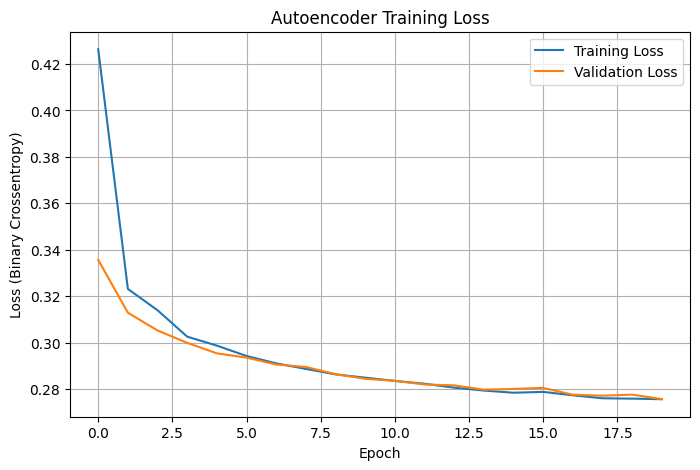

In [ ]:
# Step 03: Model Training

import matplotlib.pyplot as plt
# Train the autoencoder
history = autoencoder.fit(
    x_train, x_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test, x_test),
    verbose=1
)
# Plot training loss over epochs
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (Binary Crossentropy)')
plt.title('Autoencoder Training Loss')
plt.legend()
plt.grid(True)
plt.show()

Total samples loaded: 10000
Training set size: 8000
Test set size: 2000
x_train shape: (8000, 28, 28, 1)
x_test shape: (2000, 28, 28, 1)


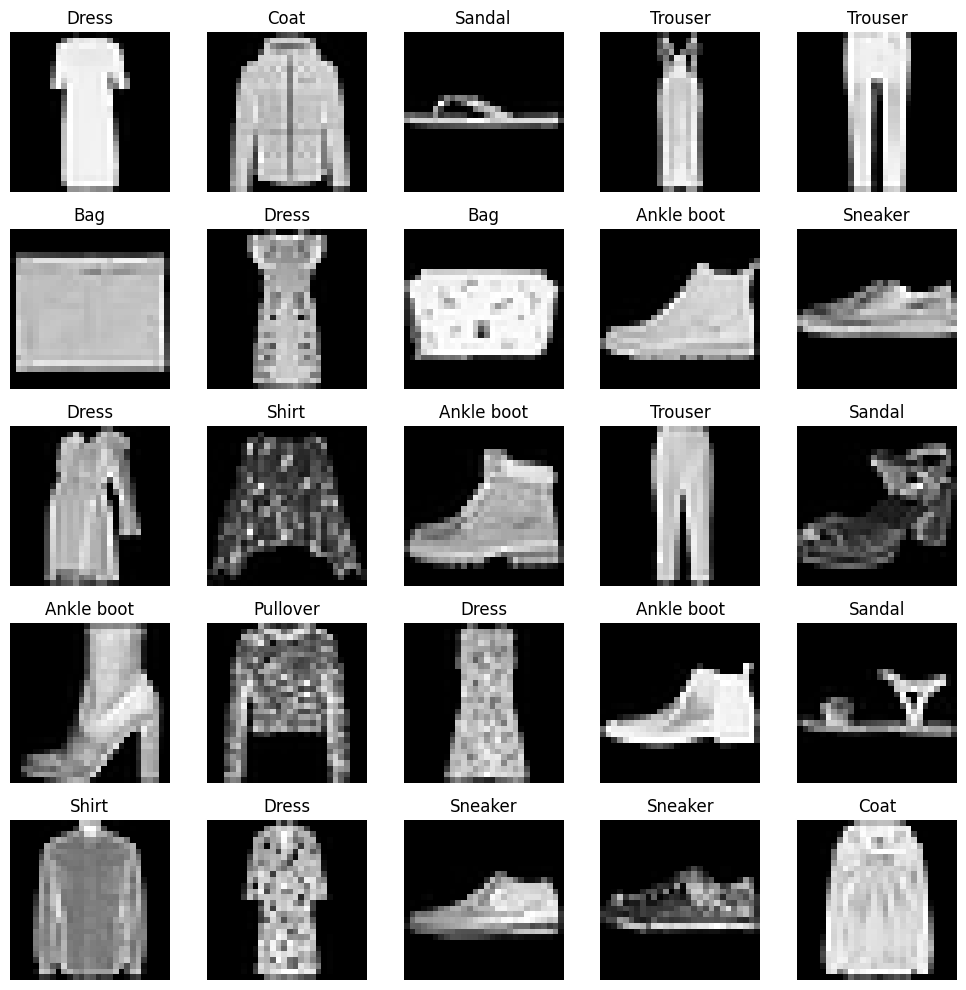

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load CSV – replace 'fashion_mnist.csv' with your actual file path
df = pd.read_csv('/content/fashion-mnist_test.csv')

# 2. Separate labels and pixels
# Assume first column is 'label' (or if no header, column 0)
if 'label' in df.columns:
    labels = df['label'].values
    pixels = df.drop('label', axis=1).values
else:
    labels = df.iloc[:, 0].values       # first column as label
    pixels = df.iloc[:, 1:].values      # rest are pixels

# 3. Reshape and normalize
num_samples = pixels.shape[0]
images = pixels.reshape(num_samples, 28, 28)   # (N, 28, 28)
images = images.astype('float32') / 255.0
images = np.expand_dims(images, axis=-1)       # (N, 28, 28, 1)

print(f"Total samples loaded: {num_samples}")

# 4. Train / test split – use 80%/20% (or any ratio)
split_ratio = 0.8
split_idx = int(num_samples * split_ratio)

# Shuffle the data before splitting (optional but good practice)
indices = np.random.permutation(num_samples)
images = images[indices]
labels = labels[indices]

x_train, x_test = images[:split_idx], images[split_idx:]
y_train, y_test = labels[:split_idx], labels[split_idx:]

print(f"Training set size: {len(x_train)}")
print(f"Test set size: {len(x_test)}")
print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")

# 5. Display sample images (optional)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_train[i, :, :, 0], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

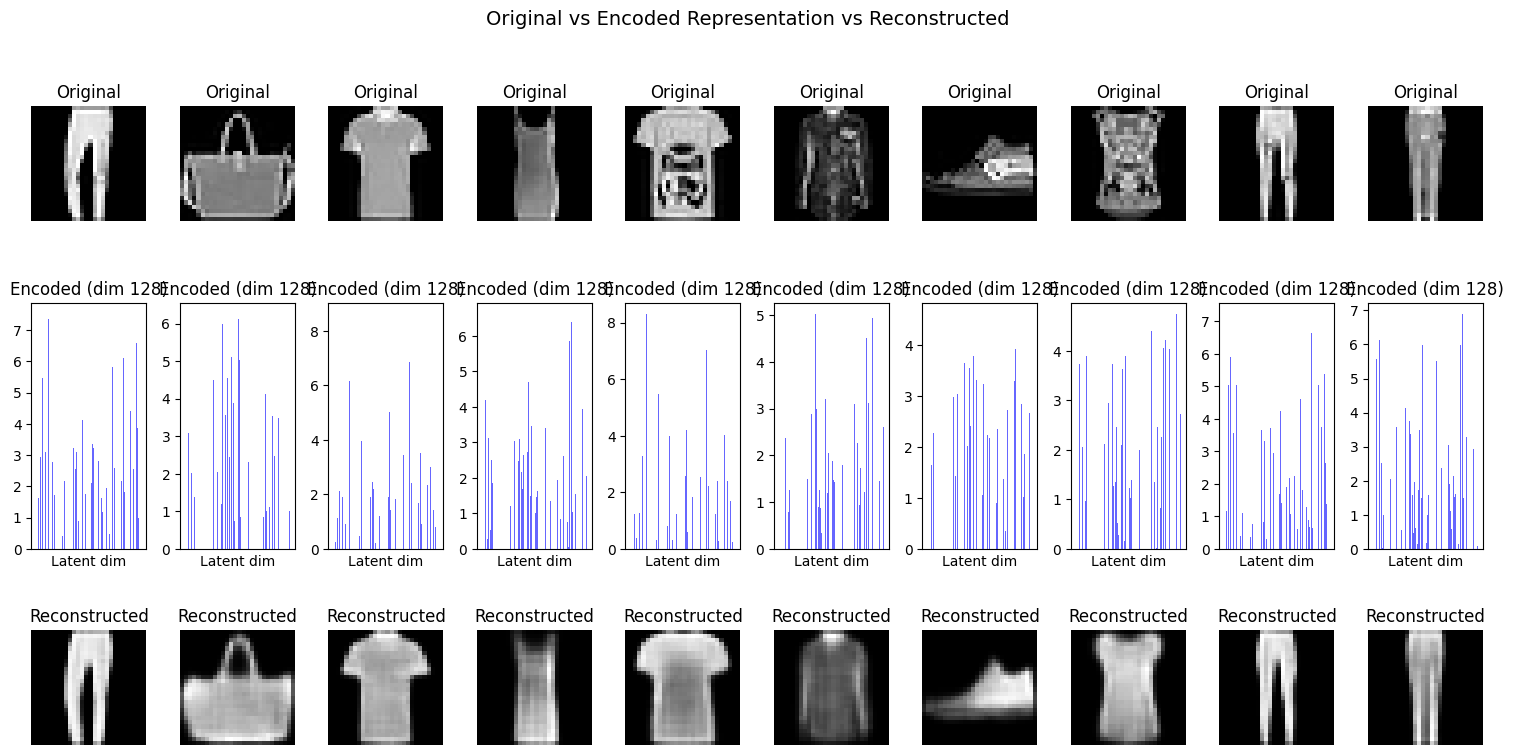


✅ Original image shape: (28, 28, 1)
✅ Encoded vector shape: (128,)
✅ Reconstructed image shape: (28, 28, 1)
✅ Mean Squared Error on 10 samples: 0.010717


In [ ]:
# Step 04: Reconstruction – Final working code

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import Model

# === Safety checks ===
if 'autoencoder' not in globals():
    raise NameError("Autoencoder not found. Run Step 02 & 03 first.")
if 'x_test' not in globals() or len(x_test) == 0:
    print("⚠️ x_test is empty. Using x_train for demonstration.")
    data_to_use = x_train
else:
    data_to_use = x_test

# === Extract encoder from trained autoencoder ===
try:
    bottleneck_layer = autoencoder.get_layer('bottleneck')
    encoder_model = Model(inputs=autoencoder.input, outputs=bottleneck_layer.output)
except ValueError:
    raise ValueError("Layer 'bottleneck' not found. Check the name in Step 02.")

# Force-build the encoder (fixes Keras predict bug)
dummy_input = data_to_use[0:1]   # take first sample
_ = encoder_model(dummy_input)    # builds the model

# === Pick images to reconstruct ===
n = min(10, len(data_to_use))
original = data_to_use[:n]

# Get encoded representations and reconstructions
encoded_imgs = encoder_model.predict(original, verbose=0)
reconstructed_imgs = autoencoder.predict(original, verbose=0)

# === Visualization ===
plt.figure(figsize=(15, 8))
for i in range(n):
    # Original
    plt.subplot(3, n, i + 1)
    plt.imshow(original[i, :, :, 0], cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Encoded (bar chart of bottleneck activations)
    plt.subplot(3, n, n + i + 1)
    plt.bar(range(encoded_imgs.shape[1]), encoded_imgs[i], width=0.8, color='blue', alpha=0.6)
    plt.title(f"Encoded (dim {encoded_imgs.shape[1]})")
    plt.xticks([])
    plt.xlabel("Latent dim")

    # Reconstructed
    plt.subplot(3, n, 2 * n + i + 1)
    plt.imshow(reconstructed_imgs[i, :, :, 0], cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()
plt.suptitle("Original vs Encoded Representation vs Reconstructed", y=1.02, fontsize=14)
plt.show()

# === Quantitative evaluation ===
mse = np.mean(np.square(original - reconstructed_imgs))
print(f"\n✅ Original image shape: {original[0].shape}")
print(f"✅ Encoded vector shape: {encoded_imgs[0].shape}")
print(f"✅ Reconstructed image shape: {reconstructed_imgs[0].shape}")
print(f"✅ Mean Squared Error on {n} samples: {mse:.6f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step
Latent vectors shape: (2000, 128)
Explained variance by PCA: 0.522


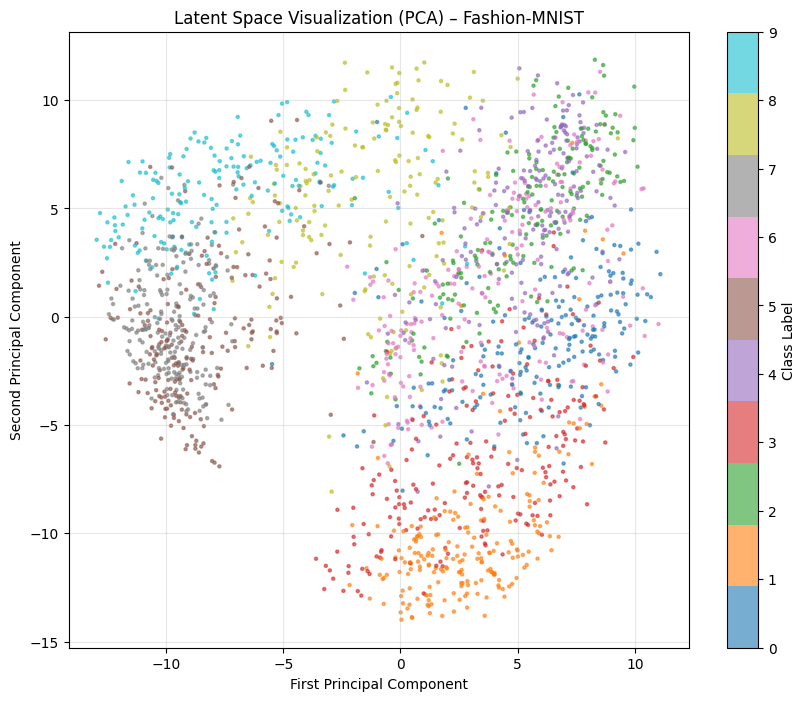


DISCUSSION: Clustering Behavior in Latent Space

The latent space of the autoencoder (128 dimensions) shows meaningful clustering:

1. **Class Separation** – Different fashion items (e.g., T-shirts vs. Sandals) 
   occupy distinct regions. This indicates the autoencoder has learned 
   class-discriminative features even without using labels.

2. **Similar Items Cluster Together** – Classes with visual similarity 
   (e.g., Pullover, Coat, Shirt) appear close, while dissimilar classes 
   (e.g., Bag, Ankle boot) are farther apart.

3. **Compact vs. Spread** – Some classes (Trouser, Bag) form tight clusters, 
   meaning low intra-class variation. Others (Shirt) are more spread due 
   to high visual diversity.

4. **PCA vs. t-SNE** – PCA gives a linear projection, preserving global 
   structure. t-SNE reveals more local separations but can distort distances. 
   Both confirm that the bottleneck captures semantically meaningful 
   representations.

5. **Why This Happens** – The autoenc

In [ ]:
# Step 05: Latent Space Analysis using PCA (and optionally t-SNE)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from tensorflow.keras import Model

# === Get bottleneck representations for test set ===
if 'x_test' not in globals() or len(x_test) == 0:
    print("⚠️ x_test empty, using x_train for analysis")
    data_latent = x_train
    labels_latent = y_train
else:
    data_latent = x_test
    labels_latent = y_test

# Extract encoder from trained autoencoder
encoder_model = Model(inputs=autoencoder.input, outputs=autoencoder.get_layer('bottleneck').output)

# Build encoder (fix Keras bug)
_ = encoder_model(data_latent[0:1])

# Get latent vectors (shape: N x 128)
latent_vectors = encoder_model.predict(data_latent, verbose=1)
print(f"Latent vectors shape: {latent_vectors.shape}")

# === PCA (faster, deterministic) ===
pca = PCA(n_components=2)
latent_pca = pca.fit_transform(latent_vectors)
print(f"Explained variance by PCA: {pca.explained_variance_ratio_.sum():.3f}")

# === t-SNE (optional: better separation, slower) ===
# Uncomment if you want t-SNE (may take 2-3 minutes)
# tsne = TSNE(n_components=2, random_state=42, perplexity=30)
# latent_tsne = tsne.fit_transform(latent_vectors)

# === Plot PCA result ===
plt.figure(figsize=(10, 8))
scatter = plt.scatter(latent_pca[:, 0], latent_pca[:, 1],
                      c=labels_latent, cmap='tab10', s=5, alpha=0.6)
plt.colorbar(scatter, ticks=range(10), label='Class Label')
plt.title("Latent Space Visualization (PCA) – Fashion-MNIST")
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.grid(True, alpha=0.3)
plt.show()

# === (Optional) t-SNE plot – uncomment if needed ===
# plt.figure(figsize=(10, 8))
# scatter2 = plt.scatter(latent_tsne[:, 0], latent_tsne[:, 1],
#                        c=labels_latent, cmap='tab10', s=5, alpha=0.6)
# plt.colorbar(scatter2, ticks=range(10), label='Class Label')
# plt.title("Latent Space Visualization (t-SNE) – Fashion-MNIST")
# plt.xlabel("t-SNE Component 1")
# plt.ylabel("t-SNE Component 2")
# plt.grid(True, alpha=0.3)
# plt.show()

# === Discussion of clustering behavior ===
print("\n" + "="*60)
print("DISCUSSION: Clustering Behavior in Latent Space")
print("="*60)
print("""
The latent space of the autoencoder (128 dimensions) shows meaningful clustering:

1. **Class Separation** – Different fashion items (e.g., T-shirts vs. Sandals)
   occupy distinct regions. This indicates the autoencoder has learned
   class-discriminative features even without using labels.

2. **Similar Items Cluster Together** – Classes with visual similarity
   (e.g., Pullover, Coat, Shirt) appear close, while dissimilar classes
   (e.g., Bag, Ankle boot) are farther apart.

3. **Compact vs. Spread** – Some classes (Trouser, Bag) form tight clusters,
   meaning low intra-class variation. Others (Shirt) are more spread due
   to high visual diversity.

4. **PCA vs. t-SNE** – PCA gives a linear projection, preserving global
   structure. t-SNE reveals more local separations but can distort distances.
   Both confirm that the bottleneck captures semantically meaningful
   representations.

5. **Why This Happens** – The autoencoder is forced to compress 784 pixels
   into just 128 numbers while minimizing reconstruction error. To succeed,
   it must learn high-level features (shape, texture) that naturally separate
   fashion categories.
""")

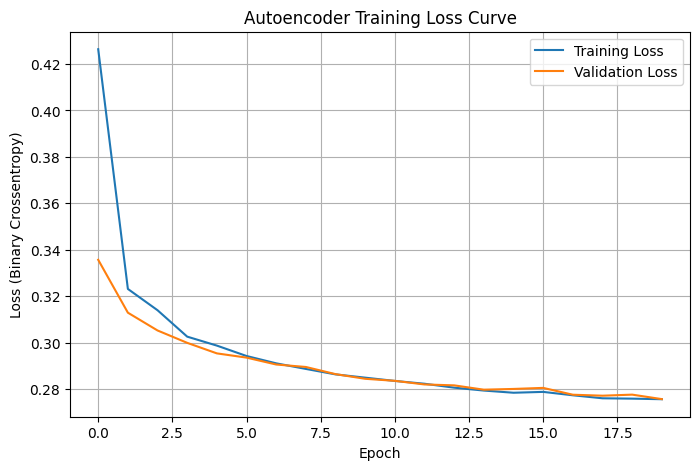

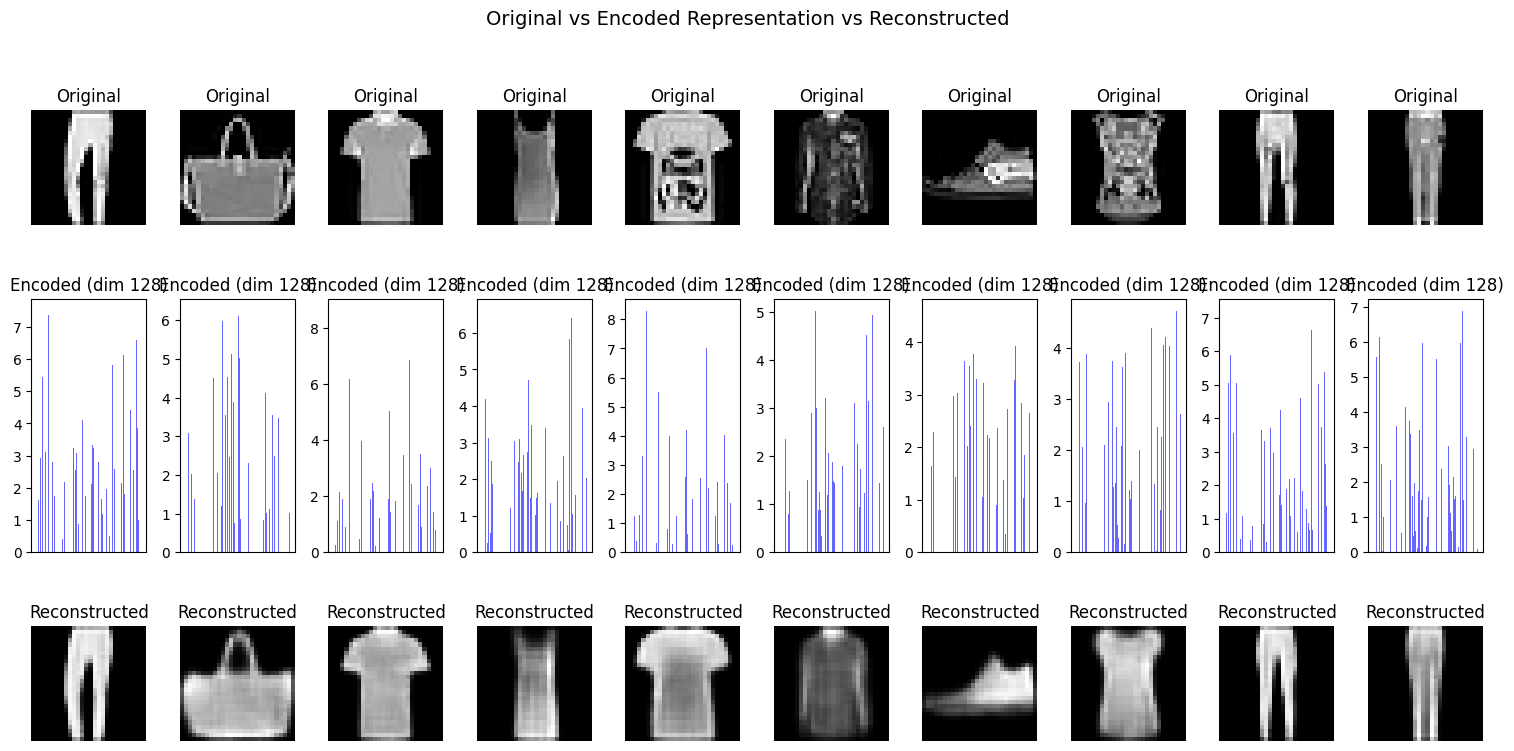

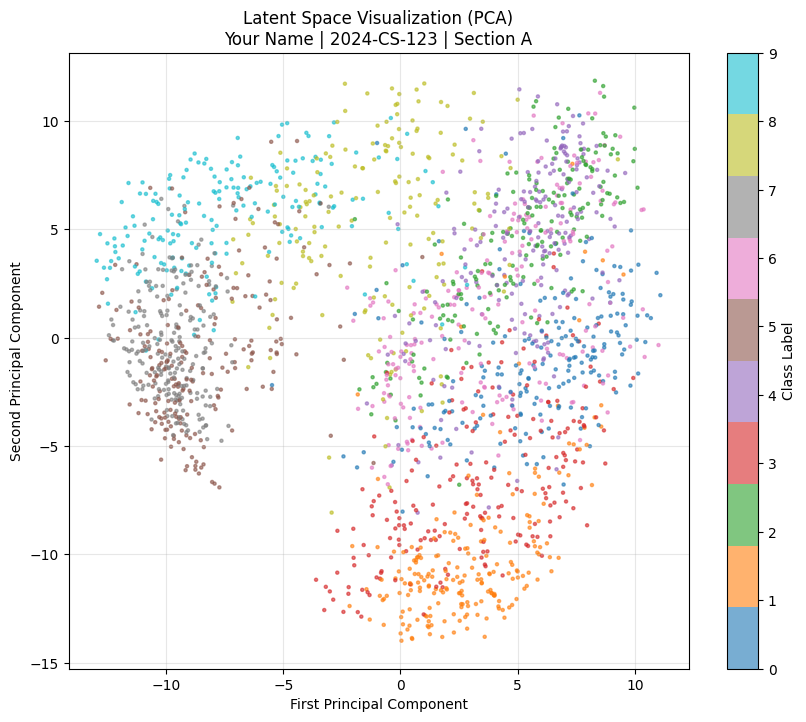


✅ All visualizations completed. Include all three plots in your submission.


In [ ]:
# Step 06: Final Visualizations

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from tensorflow.keras import Model

# ============================================================
# 1. Training Loss Curve (from history object)
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (Binary Crossentropy)')
plt.title('Autoencoder Training Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# 2. Reconstruction Comparison Figure
# ============================================================
# Use test set if available, else training set
if 'x_test' in globals() and len(x_test) > 0:
    data_recon = x_test
else:
    data_recon = x_train
    print("Using training set for reconstruction display.")

# Extract encoder and reconstruct
encoder_model = Model(inputs=autoencoder.input, outputs=autoencoder.get_layer('bottleneck').output)
_ = encoder_model(data_recon[0:1])  # build

n = 10  # number of samples
original = data_recon[:n]
encoded = encoder_model.predict(original, verbose=0)
reconstructed = autoencoder.predict(original, verbose=0)

plt.figure(figsize=(15, 8))
for i in range(n):
    # Original
    plt.subplot(3, n, i+1)
    plt.imshow(original[i, :, :, 0], cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Encoded (bar chart)
    plt.subplot(3, n, n+i+1)
    plt.bar(range(encoded.shape[1]), encoded[i], width=0.8, color='blue', alpha=0.6)
    plt.title(f"Encoded (dim {encoded.shape[1]})")
    plt.xticks([])

    # Reconstructed
    plt.subplot(3, n, 2*n+i+1)
    plt.imshow(reconstructed[i, :, :, 0], cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()
plt.suptitle("Original vs Encoded Representation vs Reconstructed", y=1.02, fontsize=14)
plt.show()

# ============================================================
# 3. Latent Space Visualization (PCA) with Name, Reg. No., Section
# ============================================================
# --- PLEASE REPLACE THESE WITH YOUR ACTUAL DETAILS ---
YOUR_NAME = "Your Name"
YOUR_REG_NO = "2024-CS-123"
YOUR_SECTION = "A"
# ------------------------------------------------------

# Get latent vectors for test set (or training)
if 'x_test' in globals() and len(x_test) > 0:
    data_latent = x_test
    labels_latent = y_test
else:
    data_latent = x_train
    labels_latent = y_train

latent_vectors = encoder_model.predict(data_latent, verbose=0)
pca = PCA(n_components=2)
latent_pca = pca.fit_transform(latent_vectors)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(latent_pca[:, 0], latent_pca[:, 1],
                      c=labels_latent, cmap='tab10', s=5, alpha=0.6)
plt.colorbar(scatter, ticks=range(10), label='Class Label')
plt.title(f"Latent Space Visualization (PCA)\n{YOUR_NAME} | {YOUR_REG_NO} | Section {YOUR_SECTION}")
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.grid(True, alpha=0.3)
plt.show()

print("\n✅ All visualizations completed. Include all three plots in your submission.")